# 1 - Variational auto-encoder


> Part of **[Compressed Sensing using Generative Models](../README.md)**.
> Run `pip install -e .` from the repository root first; every notebook imports
> the `csgm` package rather than redefining the model and recovery code inline.


A VAE learns a smooth, low-dimensional description of the MNIST manifold. Two
networks are trained jointly:

- the **encoder** $q_\phi(z \mid x)$ maps an image to the parameters
  $(\mu, \log \sigma^2)$ of a diagonal Gaussian in $\mathbb{R}^k$;
- the **decoder** $p_\theta(x \mid z)$ maps a latent code back to an image.

Training maximises the evidence lower bound

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z \mid x)}\big[\log p_\theta(x \mid z)\big]}_{\text{reconstruction}} - \underbrace{D_{\mathrm{KL}}\big(q_\phi(z \mid x) \,\|\, p(z)\big)}_{\text{regularisation}},$$

with the prior $p(z) = \mathcal{N}(0, I)$. The KL term is what makes the VAE
useful here: it forces the aggregate posterior towards the standard normal, so
at recovery time we can safely search over $z \sim \mathcal{N}(0, I)$ and expect
the decoder to answer with a plausible digit.

**Only the decoder is needed downstream** - it is the generator $G$ of
[notebook 4](04_compressed_sensing_recovery.ipynb).

In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np

from csgm.config import DEFAULT_SEED, MODELS_DIR
from csgm.data import load_mnist
from csgm.models import VAE, build_decoder, build_encoder
from csgm.viz import show_images

keras.utils.set_random_seed(DEFAULT_SEED)
print("keras", keras.__version__)

keras 3.15.1


## 1.1 Data

Pixels are scaled to $[0, 1]$ to match the decoder's sigmoid output.

train (60000, 28, 28, 1) | test (10000, 28, 28, 1) | range (0.0, 1.0)


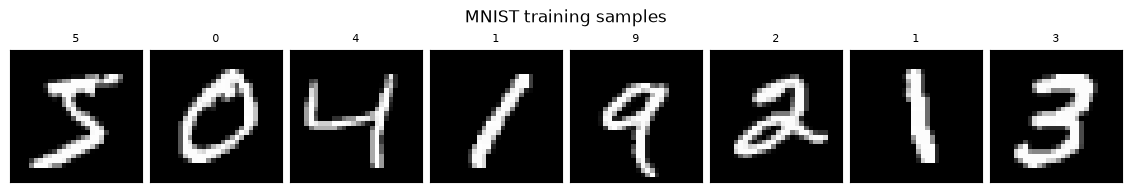

In [2]:
(x_train, y_train), (x_test, y_test) = load_mnist()
print("train", x_train.shape, "| test", x_test.shape, "| range", (x_train.min(), x_train.max()))

show_images(x_train[:8], [str(d) for d in y_train[:8]], suptitle="MNIST training samples");

## 1.2 Architecture

The encoder is four convolutions (32, 64, 64, 64 filters, one of them strided)
followed by a dense bottleneck; the decoder mirrors it with two transposed
convolutions. `latent_dim` is the only knob that matters for the compressed
sensing experiment - the shipped checkpoints use $k = 20$ and $k = 30$.

Set `latent_dim = 2` instead to reproduce the latent-space scatter plot at the
end of this notebook.

In [3]:
latent_dim = 20

encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)
encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12544)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │    401,440 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 20)        │        660 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 20)        │        660 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 20)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 495,432 (1.89 MB)

 Trainable params: 495,432 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12544)          │       263,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,177 (1.08 MB)

 Trainable params: 282,177 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

### The reparameterisation trick

Sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ is not differentiable with respect
to $\mu$ and $\sigma$. Writing $z = \mu + \sigma \odot \epsilon$ with
$\epsilon \sim \mathcal{N}(0, I)$ moves the randomness to a leaf of the graph, so
gradients reach the encoder. That is the whole job of `csgm.models.Sampling`.

In [4]:
from csgm.models import Sampling

probe = Sampling()([np.zeros((5, latent_dim), "float32"), np.zeros((5, latent_dim), "float32")])
print("five draws from N(0, I):", np.asarray(probe)[:, 0])

five draws from N(0, I): [ 0.46169513 -2.2425973  -0.08080248 -0.41791376  1.8840612 ]


## 1.3 Training

The shipped checkpoints were trained at batch size 100 with Adam ($10^{-3}$),
for up to 100 epochs with early stopping on the validation ELBO. The cell below
uses far fewer epochs so the notebook stays runnable. For the real thing use
the script:

```bash
python scripts/train_vae.py --latent-dim 20 --epochs 100
```

In [5]:
EPOCHS = 5  # -> 100 to reproduce the checkpoints

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=100,
    validation_data=(x_test,),
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
)

Epoch 1/5


  1/600 ━━━━━━━━━━━━━━━━━━━━ 1:32:08 9s/step - kl_loss: 0.0061 - loss: 546.1153 - reconstruction_loss: 546.1092

  2/600 ━━━━━━━━━━━━━━━━━━━━ 2:40 268ms/step - kl_loss: 0.0493 - loss: 543.8593 - reconstruction_loss: 543.8099

  3/600 ━━━━━━━━━━━━━━━━━━━━ 1:47 180ms/step - kl_loss: 0.0356 - loss: 541.5891 - reconstruction_loss: 541.5535

  4/600 ━━━━━━━━━━━━━━━━━━━━ 1:50 185ms/step - kl_loss: 0.0268 - loss: 539.3713 - reconstruction_loss: 539.3444

...

597/600 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - kl_loss: 9.3179 - loss: 147.8298 - reconstruction_loss: 138.5119

598/600 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - kl_loss: 9.3172 - loss: 147.8273 - reconstruction_loss: 138.5100

599/600 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - kl_loss: 9.3169 - loss: 147.8296 - reconstruction_loss: 138.5126

600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - kl_loss: 9.3175 - loss: 147.8152 - reconstruction_loss: 138.4977

600/600 ━━━━━━━━━━━━━━━━━━━━ 100s 166ms/step - kl_loss: 9.3175 - loss: 147.8152 - reconstruction_loss: 138.4977 - val_kl_loss: 9.5833 - val_loss: 146.8799 - val_reconstruction_loss: 137.2967


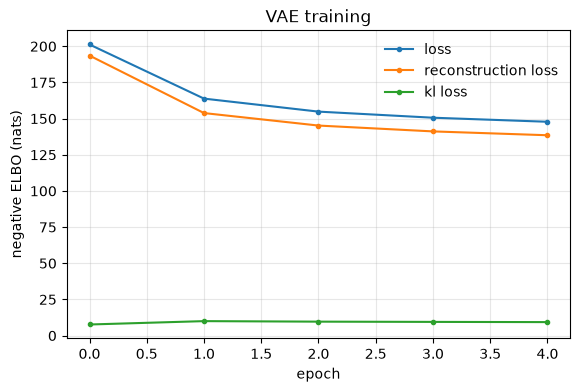

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for key in ("loss", "reconstruction_loss", "kl_loss"):
    ax.plot(history.history[key], marker="o", ms=3, label=key.replace("_", " "))
ax.set_xlabel("epoch")
ax.set_ylabel("negative ELBO (nats)")
ax.set_title("VAE training")
ax.grid(alpha=0.3)
ax.legend(frameon=False);

The reconstruction term dominates the total loss, while the KL term settles on a
small positive plateau: the posterior stays close enough to the prior for latent
search to work, without collapsing onto it (which would make the decoder ignore
$z$ entirely).

## 1.4 What the decoder learned

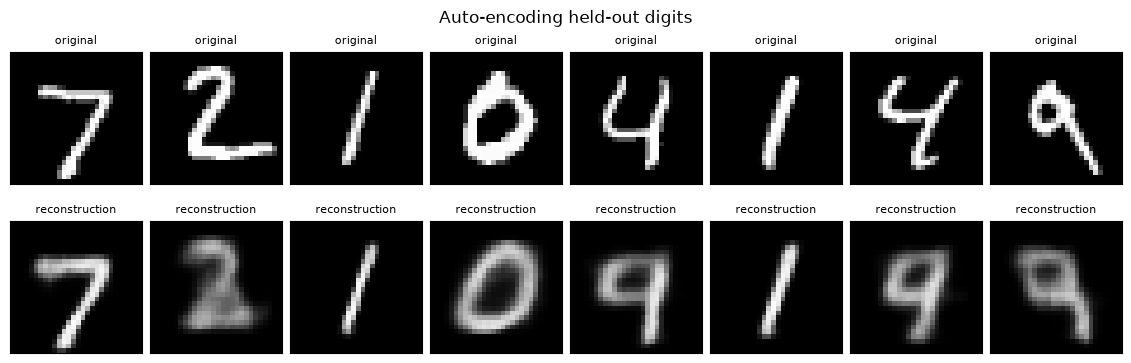

In [7]:
reconstructed = vae.predict(x_test[:8], verbose=0)
show_images(
    np.concatenate([x_test[:8], reconstructed]),
    ["original"] * 8 + ["reconstruction"] * 8,
    suptitle="Auto-encoding held-out digits",
);

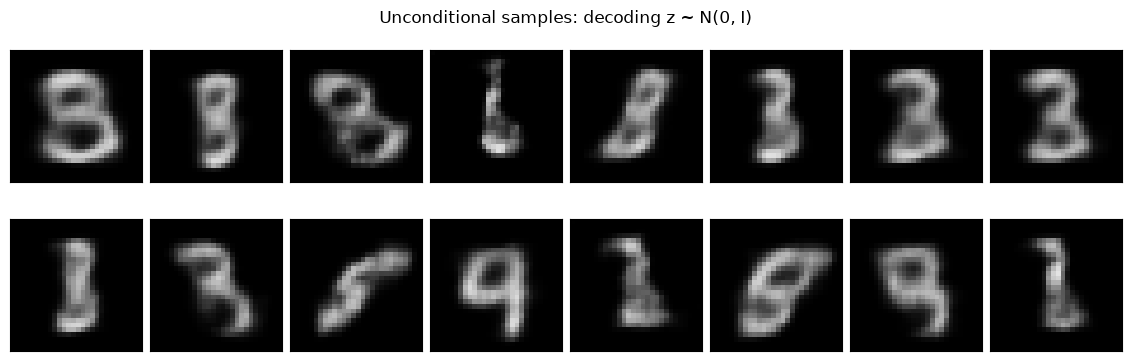

In [8]:
z = np.random.default_rng(0).standard_normal((16, latent_dim)).astype("float32")
show_images(decoder(z, training=False), suptitle="Unconditional samples: decoding z ~ N(0, I)");

These samples are the *entire hypothesis space* of the compressed sensing
recovery in notebook 4: it can only ever return an image the decoder is able to
produce. Blurry samples here mean a blurry error floor there.

## 1.5 Structure of the latent space

With $k = 2$ the posterior means can be plotted directly. Digits form
well-separated clusters, which is why moving through the latent space produces
smooth morphs between classes rather than noise - exactly the structure that
gradient descent on $z$ exploits.

<img src="../docs/figures/vae_latent_space_2d.png" width="620">

Re-run this notebook with `latent_dim = 2` to regenerate the figure:

```python
mu, _, _ = encoder.predict(x_test)
plt.scatter(mu[:, 0], mu[:, 1], c=y_test, cmap="brg", s=2)
```

## 1.6 Save the decoder

In [9]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
path = MODELS_DIR / f"vae_decoder_dim{latent_dim}.keras"
# decoder.save(path)   # uncomment to overwrite the shipped checkpoint
print("would save to", path)

would save to C:\Users\renat\Desktop\Compressed-Sensing-using-Generative-Models\models\vae_decoder_dim20.keras


---
Next: [2 - DCGAN](02_dcgan_training.ipynb), the adversarially trained
alternative prior.